In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Exploration and Data loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [9]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [10]:
df.describe(include = 'all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [11]:
unique_counts = df.nunique()
# filter the series to find columns where the count is exactly 2
filter = unique_counts[unique_counts == 2].index.tolist()
print(filter)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


Binary Encoding

In [12]:
binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Map yes/no and male/female to 0/1
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female':0
})

/tmp/ipykernel_415/4059102200.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


One hot encoding

In [14]:
# categorical columns with > 2 unique values
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup','DeviceProtection','TechSupport', 'StreamingTV','StreamingMovies','Contract', 'PaymentMethod']

#One-hot encode
df = pd.get_dummies(df, columns = multi_cat_cols, drop_first = True)

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


Cleaning

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [17]:
df = df.drop('customerID', axis = 1)

In [18]:
bool_cols = df.select_dtypes(include = 'bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [20]:
corr_matrix = df.corr(numeric_only = True)
churn_corr = corr_matrix['Churn'].sort_values(ascending = False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


Correlation analysis was performed to identify features influencing customer churn. The results show that tenure (-0.35) and two-year contracts (-0.30) strongly reduce churn, indicating long-term customers are less likely to leave. Conversely, fiber optic internet (0.30) and electronic check payments (0.30) show positive correlation with churn, suggesting these customers are more likely to discontinue services.

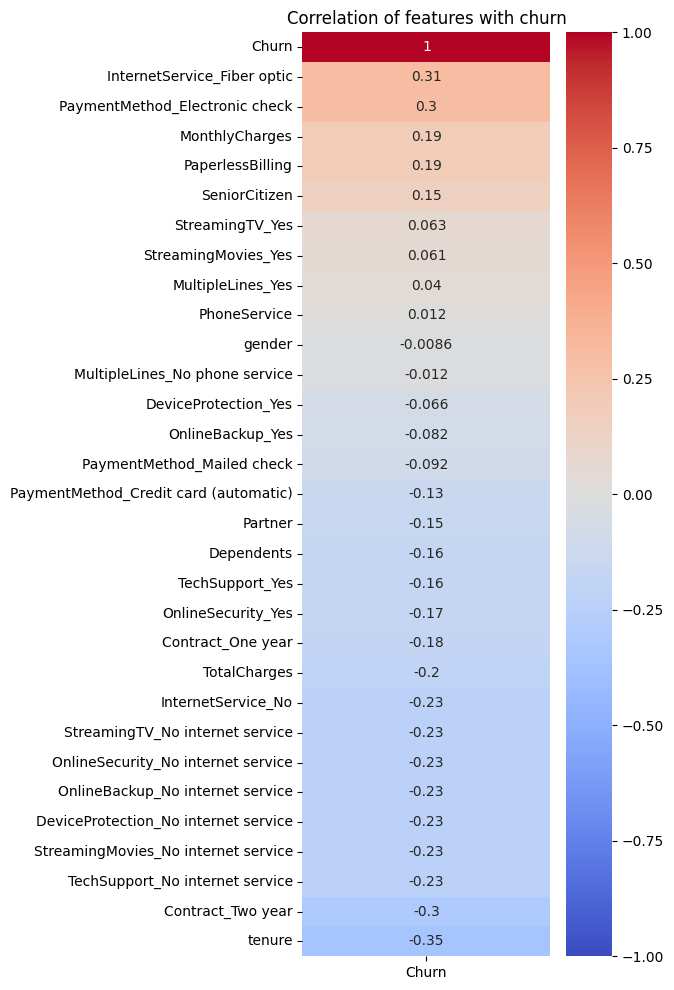

In [21]:
import seaborn as sns
# compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only= True)

# Focus on correlation with churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending = False)

#Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Correlation of features with churn')
plt.show()

Look for multicolinearity(VIF)

In [22]:
# we need to collapse redundant columns before running VIF
df['No_internet_service'] =(
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns = drop_cols)

# Handle phoneservice redundancy
if 'MultipleLines_No phone service' in df.columns:
  df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
  df = df.drop(columns= ['MultipleLines_No phone service'])

In [23]:
# Prepare X
X = df.drop(columns = ['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [24]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by = 'VIF', ascending= False)

print(vif_data)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

Variance Inflation Factor (VIF) analysis was performed to detect multicollinearity among features. Columns representing “No internet service” created perfect multicollinearity.

Machine Learning

In [25]:
# we have a class imbalance problem
# Given your imbalance (27% churners, class weighting + threshold tuning is probably enough - no need for aggressive oversampling yet)
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

# Prepare data
X = df.drop(columns = ['Churn'])
y = df["Churn"]

# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

THRESHOLD = 0.3

RandomForest Classifier

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:,1]

print('Threshold tuning for RandomForest')

print(f"{'Thresh': <8}{'Prec_1':<8}{'Rec_1': <8}{'F1_1':<8}")

for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
  preds = (proba >= thresh).astype(int)
  prec = precision_score(y_test, preds, pos_label = 1)
  rec = recall_score(y_test, preds, pos_label = 1)
  f1 = f1_score(y_test, preds, pos_label = 1)
  print(f'{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}')

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.505   0.791   0.617   
0.3     0.532   0.725   0.614   
0.35    0.549   0.671   0.604   
0.4     0.573   0.620   0.596   
0.45    0.597   0.551   0.573   
0.5     0.624   0.492   0.550   


Threshold tuning was performed to determine the optimal probability cutoff for churn classification. Lower thresholds improved recall by identifying more potential churners, while higher thresholds increased precision. A threshold of approximately 0.25–0.30 provided the best balance based on F1-score.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators = 300,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits = 3))

              precision    recall  f1-score   support

           0      0.886     0.770     0.824      1035
           1      0.532     0.725     0.614       374

    accuracy                          0.758      1409
   macro avg      0.709     0.747     0.719      1409
weighted avg      0.792     0.758     0.768      1409



In [44]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get churn probabilities
proba = rf.predict_proba(X_test)[:,1]

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, proba)

# Compute F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find index of best F1 score
best_index = np.argmax(f1_scores)

# Get best threshold
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Precision:", precision[best_index])
print("Recall:", recall[best_index])
print("F1 Score:", f1_scores[best_index])

Best Threshold: 0.20180193051922138
Precision: 0.48270676691729325
Recall: 0.8582887700534759
F1 Score: 0.6179018286814245


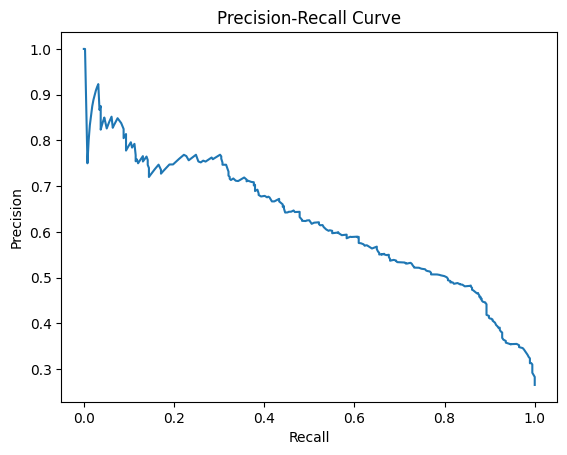

In [45]:
import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

LightGBM classifier

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

print('Threshold tuning for LightGBM')

print(f"{'Thresh': <8}{'Prec_1': <8}{'Rec_1': <8}{'F1_1': <8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
  preds = (proba >= thresh).astype(int)
  prec = precision_score(y_test, preds, pos_label = 1)
  rec = recall_score(y_test, preds, pos_label = 1)
  f1 = f1_score(y_test, preds, pos_label = 1)
  print(f"{thresh:<8}{prec: <8.3f}{rec:<8.3f}{f1:<8.3f}")


Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.557   0.623   0.588   
0.3     0.562   0.610   0.585   
0.35    0.568   0.602   0.584   
0.4     0.573   0.586   0.579   
0.45    0.574   0.572   0.573   
0.5     0.578   0.556   0.567   


In [30]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators = 500,
    learning_rate = 0.50,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f'Training time: {train_time: .2f} seconds')

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f'Prediction time: {pred_time:.4f} seconds')

# Classification report
print(classification_report(y_test, y_pred, digits = 3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time:  1.26 seconds
Prediction time: 0.0346 seconds
              precision    recall  f1-score   support

           0      0.854     0.828     0.841      1035
           1      0.562     0.610     0.585       374

    accuracy                          0.770      1409
   macro avg      0.708     0.719     0.713      1409
weighted avg      0.777     0.770  

XGBoost Classifier

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print('Threshold tuning for XGBoost')

print(f"{'Thresh':<8}{'Prec_1': <8}{'Rec_1': <8}{'F1_1': <8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
  preds = (proba >= thresh).astype(int)
  prec = precision_score(y_test, preds, pos_label = 1)
  rec = recall_score(y_test, preds, pos_label = 1)
  f1 = f1_score(y_test, preds, pos_label = 1)
  print(f"{thresh: <8}{prec: <8.3f}{rec: <8.3f}{f1: <8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.468   0.829   0.598   
0.3     0.492   0.802   0.610   
0.35    0.511   0.791   0.621   
0.4     0.524   0.765   0.622   
0.45    0.535   0.722   0.614   
0.5     0.549   0.698   0.615   


In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum()/ (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    n_jobs = -1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'logloss'
)

#Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f'Training time: {train_time:.2f} seconds')

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f'Prediction time: {pred_time:.4f} seconds')

# classification report
print(classification_report(y_test, y_pred, digits = 3))

Training time: 3.64 seconds
Prediction time: 0.0234 seconds
              precision    recall  f1-score   support

           0      0.907     0.700     0.791      1035
           1      0.492     0.802     0.610       374

    accuracy                          0.727      1409
   macro avg      0.700     0.751     0.700      1409
weighted avg      0.797     0.727     0.743      1409



Three models were evaluated: Random Forest, LightGBM, and XGBoost. LightGBM achieved the highest accuracy (77%), while XGBoost achieved the highest churn recall (80%). Since detecting potential churners is the primary objective, XGBoost with threshold tuning was selected as the final model.

Hyperparameter tuning(optuna) and Experiment tracking(MLflow)

In [36]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.6 MB/s eta 0:00:00


In [37]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # Optimize recall for churners

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2026-03-14 06:50:14,114] A new study created in memory with name: no-name-53967744-b9f0-4317-8546-10b272e0f689
[I 2026-03-14 06:50:17,879] Trial 0 finished with value: 0.8663101604278075 and parameters: {'n_estimators': 388, 'learning_rate': 0.04031876105643335, 'max_depth': 8, 'subsample': 0.8323286842121016, 'colsample_bytree': 0.6541058622890308, 'min_child_weight': 9, 'gamma': 0.395497916928253, 'reg_alpha': 4.056684456504271, 'reg_lambda': 4.283750871683752}. Best is trial 0 with value: 0.8663101604278075.
[I 2026-03-14 06:50:19,146] Trial 1 finished with value: 0.8716577540106952 and parameters: {'n_estimators': 354, 'learning_rate': 0.1331609277770124, 'max_depth': 7, 'subsample': 0.8836476460641264, 'colsample_bytree': 0.6735719342436242, 'min_child_weight': 2, 'gamma': 1.2657436860741527, 'reg_alpha': 1.0621424038510396, 'reg_lambda': 3.99255320824158}. Best is trial 1 with value: 0.8716577540106952.
[I 2026-03-14 06:50:22,471] Trial 2 finished with value: 0.844919786096256

Best Params: {'n_estimators': 389, 'learning_rate': 0.030062442896024544, 'max_depth': 4, 'subsample': 0.9783503001210412, 'colsample_bytree': 0.9914936411419605, 'min_child_weight': 6, 'gamma': 2.7932200975038626, 'reg_alpha': 3.3405401762780236, 'reg_lambda': 2.1645548794591676}
Best Recall: 0.9224598930481284


In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create model from best params
xgb = XGBClassifier(**best_params)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

Training time: 4.86 seconds
Prediction time: 0.0574 seconds
              precision    recall  f1-score   support

           0      0.953     0.565     0.710      1035
           1      0.434     0.922     0.590       374

    accuracy                          0.660      1409
   macro avg      0.693     0.744     0.650      1409
weighted avg      0.815     0.660     0.678      1409



Hyperparameter tuning was performed using Optuna to automatically search for the best model configuration. MLflow was used for experiment tracking to log parameters, evaluation metrics, and trained models, ensuring reproducibility and easier comparison between experiments.

In [40]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 7.8 MB/s eta 0:00:00


In [41]:
import mlflow
import mlflow.sklearn  # or mlflow.xgboost
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time
import os

# Force MLflow to always use the project root's mlruns folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
mlflow.set_tracking_uri(f"file://{project_root}/mlruns")
mlflow.set_experiment("Telco Churn - XGBoost")

with mlflow.start_run():
    # Calculate scale_pos_weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Best params from Optuna
    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })
    # Log parameters
    mlflow.log_params(best_params)

    # Training timer
    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Prediction
    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model
    mlflow.xgboost.log_model(xgb, "model")

    print(classification_report(y_test, y_pred, digits=3))

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/14 06:52:15 INFO mlflow.tracking.fluent: Experiment with name 'Telco Churn - XGBoost' does not exist. Creating a new experiment.
2026/03/14 06:52:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0      0.953     0.565     0.710      1035
           1      0.434     0.922     0.590       374

    accuracy                          0.660      1409
   macro avg      0.693     0.744     0.650      1409
weighted avg      0.815     0.660     0.678      1409

